# Latent Dynamics Study

## 1. Research Question And Motivation

High-fidelity (HF) simulations are accurate but expensive. Low-fidelity (LF) simulations are cheaper and more abundant, but biased.

Our long-term goal is to build a multi-fidelity surrogate that exploits both and still produces HF-quality transient predictions.

A necessary prerequisite is a unified latent space: LF and HF observations should map to latent coordinates that are not only close, but also dynamically compatible.

Key observations:

- LF abundance is only useful if the model can correct LF bias rather than simply reproduce it;
- a latent surrogate is attractive because it can compress high-dimensional transients into a lower-dimensional dynamical model;
- if LF and HF do not share a meaningful latent representation, then transferring information from LF to HF becomes much harder.


### Concrete Question For This Notebook

**When do LF and HF autoencoders learn compatible latent dynamics?**

More precisely, we ask whether LF and HF observations of the same underlying transient process can be embedded into a shared latent space in which:

- LF and HF latent trajectories agree;
- the induced latent vector field is consistent across fidelities;
- good reconstruction does not come at the expense of poor dynamical consistency.

This matters because reconstruction alone is not enough. If the learned latent dynamics are inconsistent, any downstream latent surrogate will be difficult to trust.

Working observations for this notebook:

- latent agreement may come from the training loss, not only from weight sharing;
- good LF/HF reconstruction does not guarantee a shared dynamical model;
- if alignment and partial sharing improve dynamical consistency, they become natural building blocks for the full HF surrogate.


## 2. Imports

All reusable logic lives in `experiments/latent_dynamics/utils.py`. The notebook reuses those functions rather than re-implementing the same analysis again.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils import (
    DYNAMICS_ALIGNMENT_SPECS,
    REGIME_SPECS,
    SharingStudyConfig,
    TransientFieldDatasetConfig,
    analyze_dynamics_results,
    create_dynamics_figure,
    create_field_animation,
    create_sharing_figure,
    fit_sindy_coefficients,
    format_reconstruction_metrics,
    generate_multi_fidelity_dataset,
    run_dynamics_alignment_study,
    run_full_study,
)


## 3. Test Case And Experimental Setup

We use a synthetic benchmark designed to isolate the representation-learning question before moving to a full surrogate model.

The benchmark is deliberately simple, but it contains the ingredients that matter for this study:

- a known low-dimensional latent dynamics;
- a nonlinear map from latent space to the observed HF field;
- a biased LF observation generated from the HF field.


### Synthetic Benchmark Construction

The data-generation process is:

1. generate a **known 2D latent trajectory** with damped oscillatory dynamics;
2. decode that latent state into a nonlinear **high-fidelity field**;
3. obtain the **low-fidelity field** by degrading the HF field through:
   - spatial blur,
   - amplitude scaling,
   - nonlinear distortion.

So LF and HF come from the same underlying process, but they are not identical observations of it.
This is exactly the regime where a multi-fidelity latent model should help.


### Why This Is A Useful Test Case

This synthetic setup gives us something that real data usually do not:

- we know the latent state exactly;
- we know that LF and HF share the same underlying dynamics;
- we can separate errors due to reconstruction from errors due to latent inconsistency.

So this is not a realistic CFD benchmark yet. It is a controlled experiment in which we can ask a precise question:

**do alignment and partial sharing recover a latent representation that is dynamically compatible across fidelities?**


In [2]:
dataset_config = TransientFieldDatasetConfig(
    lf_distortion_strength=0.0,
    lf_dynamics_mismatch=0.1,
)
dataset = generate_multi_fidelity_dataset(dataset_config)

print('n_train trajectories :', dataset_config.n_train)
print('n_test trajectories  :', dataset_config.n_test)
print('n_time steps         :', dataset_config.n_time)
print('HF spatial points    :', dataset_config.n_space_hf)
print('LF native points     :', dataset_config.n_space_lf)
print('latent dimension     :', dataset.train_latent.shape[-1])
print('LF distortion        :', dataset_config.lf_distortion_strength)
print('LF dyn mismatch      :', dataset_config.lf_dynamics_mismatch)
print('time horizon         :', dataset_config.t_end)
print('train_hf tensor      :', dataset.train_hf.shape)
print('train_lf tensor      :', dataset.train_lf.shape)
print('test_hf tensor       :', dataset.test_hf.shape)


n_train trajectories : 64
n_test trajectories  : 16
n_time steps         : 100
HF spatial points    : 128
LF native points     : 48
latent dimension     : 2
LF distortion        : 0.0
LF dyn mismatch      : 0.1
time horizon         : 5.0
train_hf tensor      : (64, 100, 128)
train_lf tensor      : (64, 100, 128)
test_hf tensor       : (16, 100, 128)


### Equations Used To Generate The Benchmark

It is useful to separate the benchmark into three layers:

1. a **shared latent dynamics**;
2. a **high-fidelity observation map**;
3. a **low-fidelity degradation model**.

#### 1. Shared latent dynamics

The latent state is a 2D damped oscillator:

$$
\dot{z}(t) =
\begin{bmatrix}
-\delta & -\omega \\
\omega & -\delta
\end{bmatrix} z(t),
\qquad
z(0) = A
\begin{bmatrix}
\cos \phi \\
\sin \phi
\end{bmatrix}.
$$

Equivalently,

$$
z_1(t) = A e^{-\delta t} \cos(\omega t + \phi),
\qquad
z_2(t) = A e^{-\delta t} \sin(\omega t + \phi).
$$

So the underlying dynamics are simple, known, and two-dimensional.

#### 2. High-fidelity observation model

The high-fidelity field is obtained by a nonlinear decoding on the spatial grid $x \in [0,1)$:

$$
u_{HF}(t,x) = z_1(t)\sin(\pi x) + z_2(t)\sin(2\pi x) + 0.35\, z_1(t) z_2(t) \cos(3\pi x).
$$

This is the field we regard as the reference high-fidelity trajectory.

#### 3. Low-fidelity model

We use **two independent LF knobs**:

- $\gamma$: controls how strongly the LF observation is degraded;
- $\eta$: optionally introduces a small mismatch in the LF latent dynamics.

##### 3a. Optional LF dynamics mismatch

By default, LF and HF share the same latent dynamics exactly. To test robustness, we can perturb the LF damping and frequency slightly:

$$
\omega_{LF} = (1 + 0.10\eta)\,\omega,
\qquad
\delta_{LF} = (1 + 0.20\eta)\,\delta.
$$

If $\eta = 0$, LF and HF have the same latent dynamics.
If $\eta > 0$, the LF latent trajectory is only slightly modified before decoding.

##### 3b. LF observation degradation

Starting from the LF source field, we build the observed LF data by:

1. interpolating to a coarser grid;
2. blurring it;
3. applying amplitude bias and nonlinear distortion;
4. interpolating back to the HF grid for convenience.

In equations,

$$
u_{LF}^{coarse}(t, x_{LF}) = \mathcal{I}_{HF \to LF}\left[u_{LF\!,source}(t, \cdot)\right],
$$

$$
\tilde{u}_{LF}(t, x_{LF}) = \mathcal{B}_{r_\gamma}\left(u_{LF}^{coarse}(t, x_{LF})\right),
$$

$$
u_{LF}^{dist}(t, x_{LF}) = \alpha_\gamma \, \tilde{u}_{LF}(t, x_{LF}) + \beta_\gamma \, \tanh\!\left(\tilde{u}_{LF}(t, x_{LF})\right) + \xi,
$$

$$
\alpha_\gamma = 1 - \gamma (1-\alpha),
\qquad
\beta_\gamma = \gamma \beta,
\qquad
r_\gamma = \gamma r.
$$

Here:

- $\gamma$ is the LF observation-distortion strength;
- $\xi$ is optional additive LF noise;
- $\eta$ controls only the latent-dynamics mismatch.

In the current notebook we use a stronger LF observation distortion with $\gamma = 2.0$ and keep $\eta = 0$, so LF and HF still share the same latent dynamics.


### Visualizing The Underlying, HF, And LF Dynamics

The next cells show one held-out trajectory through separate figures.

- first: the true 2D latent dynamics;
- second: the corresponding HF space-time field;
- third: the LF field after degradation and additive noise;
- fourth: the LF-HF discrepancy.

A small amount of additive noise is included in the LF visualization to make the fidelity gap more evident while keeping the underlying benchmark construction unchanged.


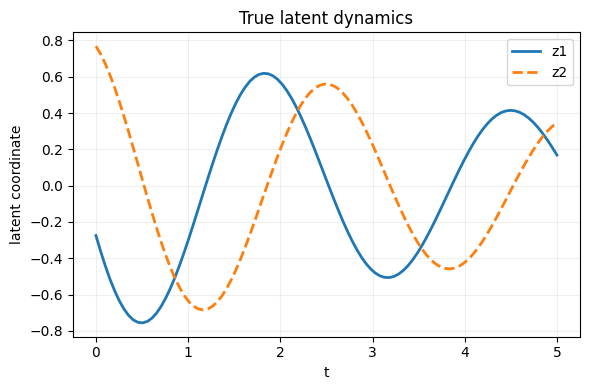

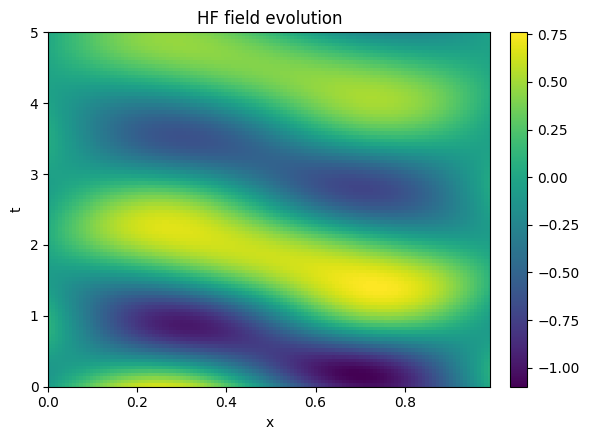

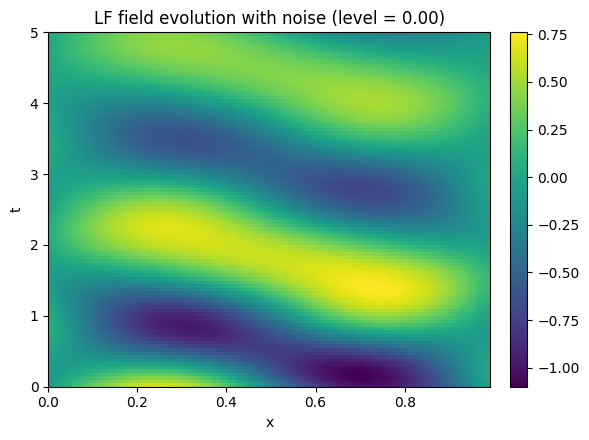

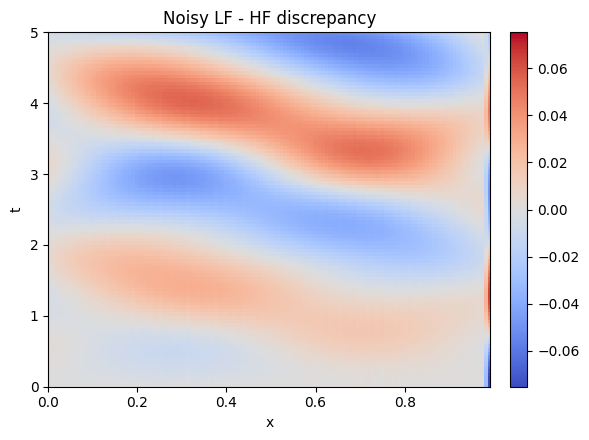

In [3]:
sample_index = 0
noise_level = 0.
rng = np.random.default_rng(7)

t = dataset.t_grid
x = dataset.x_grid
z_true = dataset.test_latent[sample_index]
hf_field = dataset.test_hf[sample_index]
lf_field_clean = dataset.test_lf[sample_index]
lf_noise = noise_level * np.std(lf_field_clean) * rng.standard_normal(lf_field_clean.shape)
lf_field = lf_field_clean + lf_noise

field_min = float(min(hf_field.min(), lf_field.min()))
field_max = float(max(hf_field.max(), lf_field.max()))
diff_field = lf_field - hf_field
diff_abs = float(np.max(np.abs(diff_field)))

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(t, z_true[:, 0], label='z1', linewidth=2)
ax.plot(t, z_true[:, 1], label='z2', linewidth=2, linestyle='--')
ax.set_title('True latent dynamics')
ax.set_xlabel('t')
ax.set_ylabel('latent coordinate')
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
im_hf = ax.imshow(
    hf_field,
    aspect='auto',
    origin='lower',
    extent=(float(x.min()), float(x.max()), float(t.min()), float(t.max())),
    cmap='viridis',
    vmin=field_min,
    vmax=field_max,
)
ax.set_title('HF field evolution')
ax.set_xlabel('x')
ax.set_ylabel('t')
fig.colorbar(im_hf, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
im_lf = ax.imshow(
    lf_field,
    aspect='auto',
    origin='lower',
    extent=(float(x.min()), float(x.max()), float(t.min()), float(t.max())),
    cmap='viridis',
    vmin=field_min,
    vmax=field_max,
)
ax.set_title(f'LF field evolution with noise (level = {noise_level:.2f})')
ax.set_xlabel('x')
ax.set_ylabel('t')
fig.colorbar(im_lf, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
im_diff = ax.imshow(
    diff_field,
    aspect='auto',
    origin='lower',
    extent=(float(x.min()), float(x.max()), float(t.min()), float(t.max())),
    cmap='coolwarm',
    vmin=-diff_abs,
    vmax=diff_abs,
)
ax.set_title('Noisy LF - HF discrepancy')
ax.set_xlabel('x')
ax.set_ylabel('t')
fig.colorbar(im_diff, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 5. Inspect The Ground-Truth Latent Trajectory

Because this is a synthetic study, we know the latent state exactly. That lets us distinguish between two questions:

- does the autoencoder reconstruct the fields?
- does the learned latent representation remain dynamically compatible with the true latent system?

The second question is much harder.

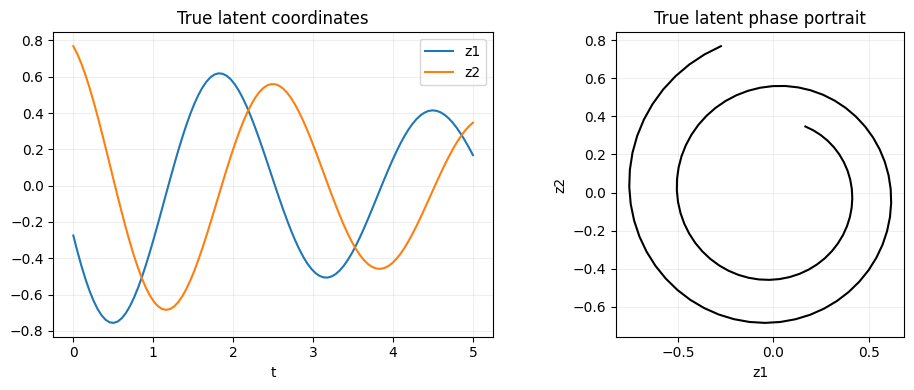

In [4]:
sample_index = 0
t = dataset.t_grid
z_true = dataset.test_latent[sample_index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(t, z_true[:, 0], label='z1')
axes[0].plot(t, z_true[:, 1], label='z2')
axes[0].set_title('True latent coordinates')
axes[0].set_xlabel('t')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(z_true[:, 0], z_true[:, 1], color='black')
axes[1].set_title('True latent phase portrait')
axes[1].set_xlabel('z1')
axes[1].set_ylabel('z2')
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(alpha=0.2)
plt.tight_layout()


## 6. Inspect The High-Dimensional Fields

Before looking at latent variables, it is useful to see the actual LF/HF discrepancy in observation space.

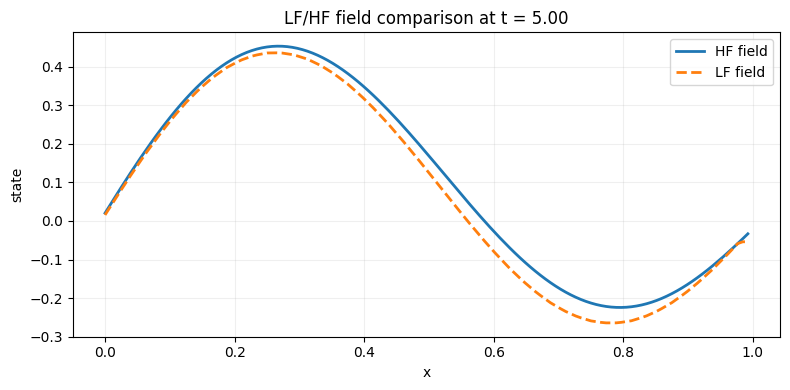

In [5]:
time_index = -1
x = dataset.x_grid
plt.figure(figsize=(8, 4))
plt.plot(x, dataset.test_hf[sample_index, time_index], label='HF field', linewidth=2)
plt.plot(x, dataset.test_lf[sample_index, time_index], label='LF field', linewidth=2, linestyle='--')
plt.title(f'LF/HF field comparison at t = {t[time_index]:.2f}')
plt.xlabel('x')
plt.ylabel('state')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()


## 7. Methods We Compare

We compare a **2x2 design**: architecture choice crossed with alignment choice.

For the fully separate architecture we learn

$$
z_{LF} = E_{LF}(x_{LF}), \qquad \hat x_{LF} = D_{LF}(z_{LF}),
$$

$$
z_{HF} = E_{HF}(x_{HF}), \qquad \hat x_{HF} = D_{HF}(z_{HF}).
$$

For the shared tail/head architecture we factor the encoder and decoder into private and shared blocks:

$$
h_{LF} = E^{priv}_{LF}(x_{LF}), \qquad h_{HF} = E^{priv}_{HF}(x_{HF}),
$$

$$
z_{LF} = E^{sh}(h_{LF}), \qquad z_{HF} = E^{sh}(h_{HF}),
$$

$$
g_{LF} = D^{sh}(z_{LF}), \qquad g_{HF} = D^{sh}(z_{HF}),
$$

$$
\hat x_{LF} = D^{priv}_{LF}(g_{LF}), \qquad \hat x_{HF} = D^{priv}_{HF}(g_{HF}).
$$

The training loss is

$$
\mathcal{L}_{rec} = \|x_{LF} - \hat x_{LF}\|_2^2 + \|x_{HF} - \hat x_{HF}\|_2^2,
$$

$$
\mathcal{L}_{align} = \|z_{LF} - z_{HF}\|_2^2,
$$

$$
\mathcal{L} = \mathcal{L}_{rec} + \lambda_{align}\,\mathcal{L}_{align}.
$$

So the four regimes are:

1. **Separate encoders/decoders, no alignment loss**: `\lambda_{align} = 0`
2. **Separate encoders/decoders, with alignment loss**: `\lambda_{align} = 1`
3. **Shared tail/head, no alignment loss**: architectural coupling only, `\lambda_{align} = 0`
4. **Shared tail/head, with alignment loss**: coupling plus explicit latent alignment, `\lambda_{align} = 1`

This lets us isolate two effects cleanly:

- what is gained by the **alignment loss**;
- what is gained by the **shared architecture** itself.

The next cell trains all four regimes and returns the dataset, trained models, encoded LF/HF trajectories, and evaluation metrics.

In [6]:
results = run_full_study(SharingStudyConfig(dataset=dataset_config))


## 8. First Quantitative Result

We start with **representation-level metrics**, before moving to dynamics.

For each regime we track:

- LF reconstruction MSE;
- HF reconstruction MSE;
- LF/HF latent MSE;
- aligned-to-true latent MSE.

The key caveat is that latent coordinates are **not directly identifiable**. So comparison with the true latent state is only meaningful **after post-hoc alignment**.

This is the first quantitative check of the main question: does the model only reconstruct well, or does it also learn a shared latent representation across fidelities?


In [7]:
for regime_key, regime_title in REGIME_SPECS:
    metrics = results['regimes'][regime_key]['metrics']
    print(regime_title)
    print(format_reconstruction_metrics(metrics))
    print('-' * 60)


Separate Encoders
No Alignment Loss
LF rec MSE: 3.567e-05
HF rec MSE: 4.017e-05
LF/HF latent MSE: 2.632e+00
LF aligned-to-true MSE: 3.851e-04
HF aligned-to-true MSE: 5.425e-04
------------------------------------------------------------
Separate Encoders
With Alignment Loss
LF rec MSE: 3.310e-05
HF rec MSE: 3.981e-05
LF/HF latent MSE: 3.522e-04
LF aligned-to-true MSE: 5.111e-04
HF aligned-to-true MSE: 3.277e-04
------------------------------------------------------------
Shared Tail/Head
No Alignment Loss
LF rec MSE: 2.925e-05
HF rec MSE: 3.220e-05
LF/HF latent MSE: 2.977e+00
LF aligned-to-true MSE: 5.752e-04
HF aligned-to-true MSE: 2.530e-04
------------------------------------------------------------
Shared Tail/Head
With Alignment Loss
LF rec MSE: 3.484e-05
HF rec MSE: 3.143e-05
LF/HF latent MSE: 3.876e-04
LF aligned-to-true MSE: 5.367e-04
HF aligned-to-true MSE: 3.735e-04
------------------------------------------------------------


### How To Read These Metrics

- If reconstruction is good but LF/HF latent MSE is large, the model reconstructs without learning a common latent space.
- Comparing **separate/no-alignment** with **separate/with-alignment** isolates the effect of the alignment loss alone.
- Comparing **separate/no-alignment** with **shared/no-alignment** isolates the effect of architectural sharing alone.
- Comparing **shared/no-alignment** with **shared/with-alignment** shows whether the alignment term still adds value once the architecture is already coupled.
- If the shared model improves aligned-to-true latent error after alignment is already active, then sharing acts as a **regularizer**, not as the only source of agreement.


## 9. Main Representation Figure

The figure below is the main visual comparison across the four regimes.

Each column corresponds to one training regime. The rows show:

- latent trajectories over time;
- latent phase portraits;
- reconstructed LF and HF fields.

The metric box in each panel summarizes reconstruction quality, LF/HF latent agreement, and aligned-to-true latent error.


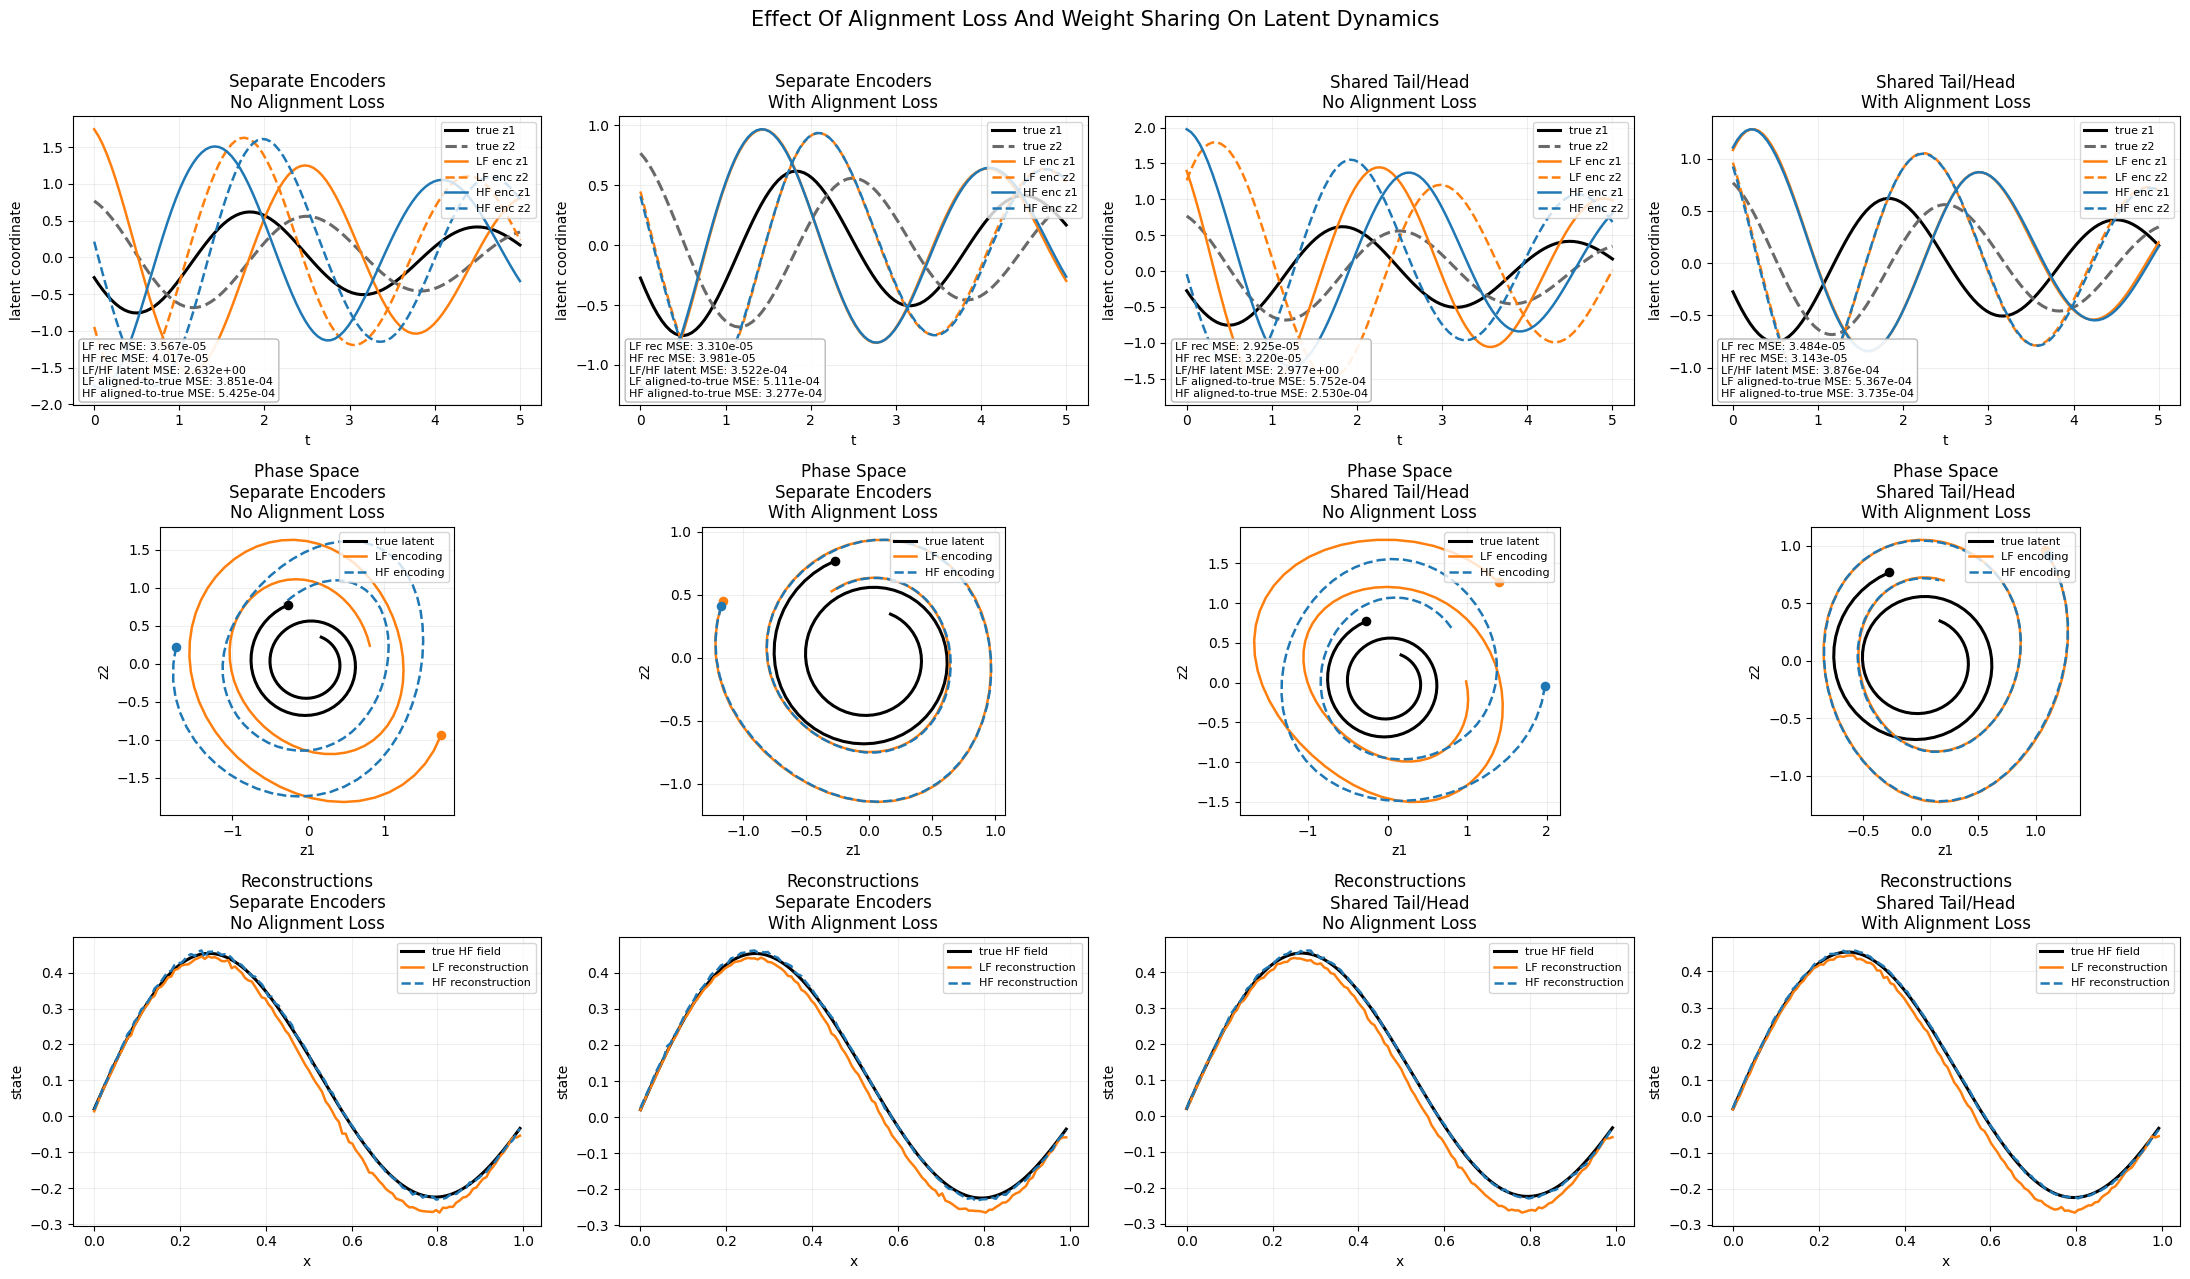

In [8]:
sample_index = 0
time_index = -1
fig, _ = create_sharing_figure(results, sample_index=sample_index, time_index=time_index)
plt.show()


### First Visual Interpretation

- In the **no-alignment** regime, LF and HF can reconstruct reasonably well while still living in clearly different latent spaces.
- Adding **latent alignment** is often enough to collapse most of the LF/HF latent discrepancy.
- **Partial sharing** should then be interpreted as an additional structural regularizer, not as the only reason LF and HF agree.

This visual result complements the metric table: the main issue is not only reconstruction, but whether the two fidelities induce a compatible latent geometry.


## 10. Why Representation Agreement Is Not Enough

Even if LF and HF latent trajectories look close, that does **not** yet mean that they define the same latent dynamics.

This is an important distinction for surrogate modeling: a good latent space should not only place trajectories near each other, but also preserve the correct **latent velocity field**.

In this notebook the encoder is still a snapshot map, `z = E(x)`, with no explicit time input. However, if the field evolves as `x = x(t)`, then the encoded trajectory also evolves as `z(t) = E(x(t))`. By the chain rule,

$$
\dot z(t) = J_E(x(t)) \, \dot x(t),
$$

where `J_E(x)` is the encoder Jacobian with respect to the field snapshot.

So the next question is stricter:

- do LF and HF produce similar latent phase portraits and sparse latent models?
- does the latent derivative computed from the encoded trajectory agree with the latent derivative implied locally by the encoder Jacobian?
- does latent alignment improve only the coordinates, or the latent dynamics as well?

This is the point where we move from representation agreement to **dynamics consistency**.


In [9]:
analysis = analyze_dynamics_results(results)

library_terms = ['1', 'z1', 'z2', 'z1^2', 'z1 z2', 'z2^2']

def print_coefficients(title, coefficients):
    print(title)
    print('  basis      dz1/dt        dz2/dt')
    for term, row in zip(library_terms, coefficients):
        print(f"  {term:>5s}  {row[0]: .3e}  {row[1]: .3e}")

print_coefficients('True latent coefficients', analysis['true_coefficients'])
print('=' * 60)

for regime_key, regime_title in REGIME_SPECS:
    regime = analysis['regimes'][regime_key]
    print(regime_title)
    print(f"HF/LF coefficient disagreement: {regime['hf_lf_coefficient_disagreement']:.3e}")
    print(f"HF fd vs pushforward MSE     : {regime['hf_fd_vs_pushforward_mse']:.3e}")
    print(f"LF fd vs pushforward MSE     : {regime['lf_fd_vs_pushforward_mse']:.3e}")
    print_coefficients('HF learned coefficients', regime['hf_coefficients'])
    print_coefficients('LF learned coefficients', regime['lf_coefficients'])
    print('-' * 60)


True latent coefficients
  basis      dz1/dt        dz2/dt
      1   0.000e+00   0.000e+00
     z1  -1.526e-01   1.998e+00
     z2  -1.997e+00  -1.475e-01
   z1^2   0.000e+00   3.670e-02
  z1 z2  -2.706e-02   0.000e+00
   z2^2   0.000e+00   0.000e+00
Separate Encoders
No Alignment Loss
HF/LF coefficient disagreement: 1.953e+00
HF fd vs pushforward MSE     : 1.722e-06
LF fd vs pushforward MSE     : 1.609e-06
HF learned coefficients
  basis      dz1/dt        dz2/dt
      1   9.998e-02  -1.939e-01
     z1   2.063e-01   2.283e+00
     z2  -1.835e+00  -5.048e-01
   z1^2   0.000e+00   1.702e-01
  z1 z2   2.587e-01   0.000e+00
   z2^2  -2.189e-02  -1.170e-01
LF learned coefficients
  basis      dz1/dt        dz2/dt
      1  -1.361e-01   5.005e-02
     z1   1.506e-01  -2.240e+00
     z2   1.861e+00  -4.563e-01
   z1^2   4.095e-02  -6.891e-02
  z1 z2  -9.425e-02  -7.560e-02
   z2^2  -3.958e-02   4.325e-02
------------------------------------------------------------
Separate Encoders
With Align

## 11. Main Dynamics Figure

The figure below asks a stricter question than the representation plots:

**even if LF and HF look close in latent space, do they actually induce the same latent dynamics?**

Each column corresponds to one training regime. Within each column we inspect both the latent geometry and the latent velocities.

- **Top row: latent phase portraits.**
  These panels show the LF and HF trajectories in the learned latent plane. If the curves overlap with similar orientation and shape, then the two fidelities are inducing a similar latent vector-field geometry.

- **Bottom row: latent derivative consistency.**
  These panels compare two different estimates of $\dot{z}$:
  1. **finite-difference derivatives**, obtained by first encoding the trajectory and then differentiating `z(t)` in time;
  2. **encoder-pushforward derivatives**, obtained from the chain rule `\dot z = J_E(x)\dot x`, where `E` is the snapshot encoder, `J_E(x)` is its Jacobian with respect to the field, and `\dot x` is the known high-dimensional time derivative.

  The second estimate does **not** give time to the encoder as an input. Instead, it asks whether the encoder locally maps motion in field space into the correct motion in latent space.

  If the finite-difference and pushforward derivatives agree, then the learned latent trajectory is kinematically consistent with the observed field dynamics. If they disagree, the latent embedding may look good geometrically while still being dynamically inconsistent.

The quantitative box summarizes three diagnostics:

- **HF/LF sparse-model coefficient disagreement**:
  we fit the same SINDy library to HF and LF latent trajectories and compare the resulting coefficients. Small values mean that HF and LF support nearly the same latent dynamical model.

- **HF finite-difference vs pushforward mismatch**:
  this checks whether the HF latent velocity estimated from `z(t)` agrees with the velocity implied by the encoder Jacobian acting on the HF field derivative.

- **LF finite-difference vs pushforward mismatch**:
  the same internal-consistency check, but for the LF encoder and LF field evolution.

So this figure tests two things at once: **cross-fidelity agreement** between LF and HF latent models, and **internal consistency** of each learned latent representation.


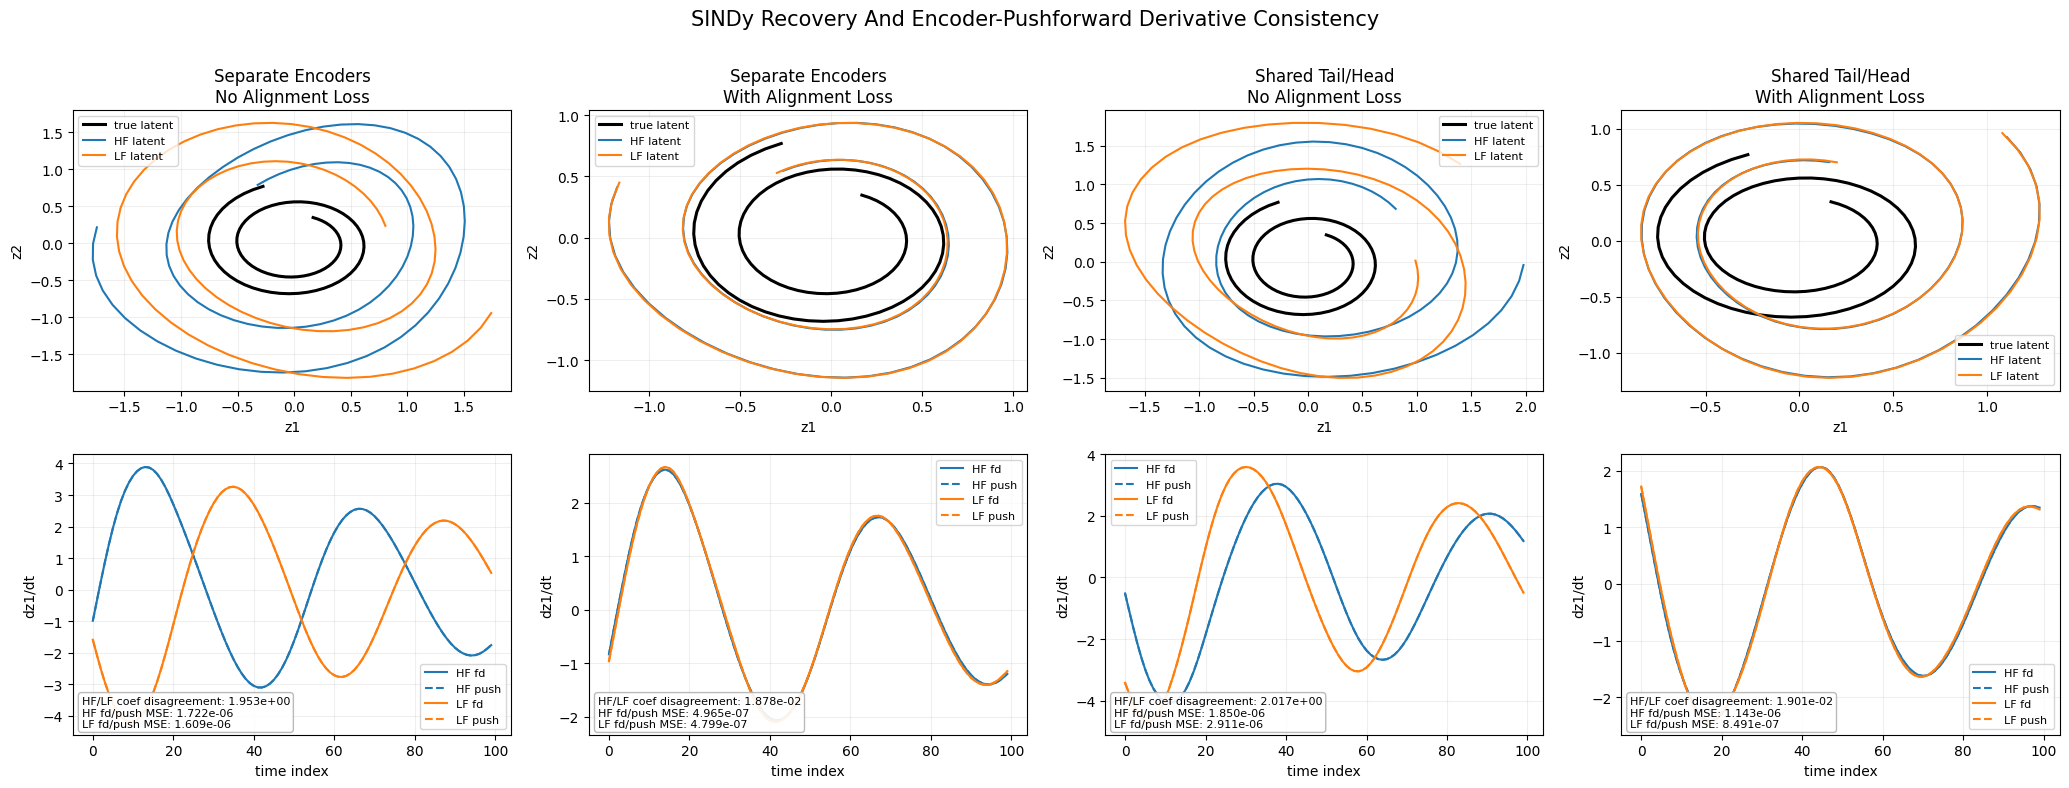

In [10]:
sample_index = 0
fig, _ = create_dynamics_figure(analysis, sample_index=sample_index)
plt.show()


### Dynamics Interpretation

- If the HF/LF coefficient disagreement is large, then LF and HF do **not** support the same latent ODE, even if their latent trajectories look visually similar.
- If the finite-difference and pushforward derivatives disagree, then the encoder is not mapping field-space motion into latent-space motion in a self-consistent way.
- Small values in both diagnostics are what we want for a surrogate: LF and HF should agree with each other, and each encoder should be locally compatible with the underlying field dynamics.

In practice, this section tells us whether alignment and sharing improve only the geometry of the latent space, or the latent dynamics as well.


## 12. Eta Sweep: Robustness To LF Dynamics Mismatch

Up to this point we focused on the ideal case `\eta = 0`, where LF and HF share the same latent dynamics and differ only at the observation level.

The next experiment asks a more realistic robustness question:

**what happens when LF is not only a distorted observation, but also carries a small dynamical mismatch?**

We keep the LF observation distortion fixed at `\gamma = 2.0` and sweep the LF latent mismatch parameter `\eta`. For each value of `\eta`, we retrain the four regimes and track:

- LF/HF latent mismatch;
- HF/LF latent-model coefficient disagreement;
- mean finite-difference vs pushforward derivative mismatch.

This is the cleanest way to test how strongly each regime relies on the shared-dynamics assumption.


eta = 0.0
  Separate Encoders | No Alignment Loss: latent MSE = 3.26e+00, coef err = 2.01e+00, mean fd/push = 1.15e-06
  Separate Encoders | With Alignment Loss: latent MSE = 3.10e-06, coef err = 1.37e-03, mean fd/push = 1.01e-06
  Shared Tail/Head | No Alignment Loss: latent MSE = 1.74e-02, coef err = 1.46e-01, mean fd/push = 4.29e-06
  Shared Tail/Head | With Alignment Loss: latent MSE = 3.34e-06, coef err = 6.67e-04, mean fd/push = 1.21e-06

eta = 0.1
  Separate Encoders | No Alignment Loss: latent MSE = 4.25e+00, coef err = 4.09e-01, mean fd/push = 2.11e-06
  Separate Encoders | With Alignment Loss: latent MSE = 4.81e-04, coef err = 9.38e-03, mean fd/push = 8.09e-07
  Shared Tail/Head | No Alignment Loss: latent MSE = 2.36e+00, coef err = 2.00e+00, mean fd/push = 2.67e-06
  Shared Tail/Head | With Alignment Loss: latent MSE = 4.75e-04, coef err = 1.30e-02, mean fd/push = 1.35e-06

eta = 0.2
  Separate Encoders | No Alignment Loss: latent MSE = 3.68e+00, coef err = 1.91e+00, mean fd

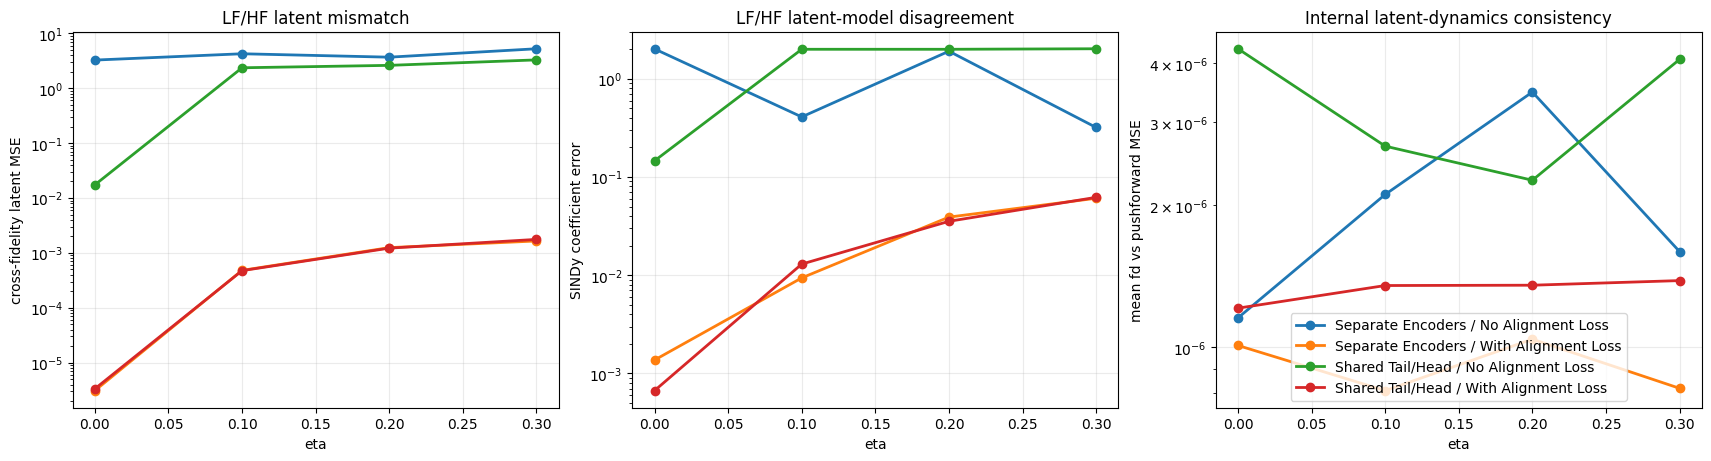

In [11]:
eta_values = [0.0, 0.1, 0.2, 0.3]
sweep_epochs = 200

eta_summary = {
    regime_key: {
        'eta': [],
        'latent_mse': [],
        'coef_err': [],
        'mean_pushforward_mse': [],
    }
    for regime_key, _ in REGIME_SPECS
}

for eta in eta_values:
    sweep_dataset = TransientFieldDatasetConfig(
        lf_distortion_strength=dataset_config.lf_distortion_strength,
        lf_dynamics_mismatch=eta,
        lf_noise_std=dataset_config.lf_noise_std,
    )
    sweep_config = SharingStudyConfig(
        dataset=sweep_dataset,
        latent_dim=2,
        epochs=sweep_epochs,
        learning_rate=1e-3,
        device='cpu',
    )

    sweep_results = run_full_study(sweep_config)
    sweep_analysis = analyze_dynamics_results(sweep_results)

    print(f'eta = {eta:.1f}')
    for regime_key, regime_title in REGIME_SPECS:
        metrics = sweep_results['regimes'][regime_key]['metrics']
        dyn = sweep_analysis['regimes'][regime_key]
        mean_pushforward_mse = 0.5 * (
            dyn['hf_fd_vs_pushforward_mse'] + dyn['lf_fd_vs_pushforward_mse']
        )

        eta_summary[regime_key]['eta'].append(eta)
        eta_summary[regime_key]['latent_mse'].append(metrics['cross_fidelity_latent_mse'])
        eta_summary[regime_key]['coef_err'].append(dyn['hf_lf_coefficient_disagreement'])
        eta_summary[regime_key]['mean_pushforward_mse'].append(mean_pushforward_mse)

        label = regime_title.replace('\n', ' | ')
        print(
            f'  {label}: latent MSE = {metrics["cross_fidelity_latent_mse"]:.2e}, '
            f'coef err = {dyn["hf_lf_coefficient_disagreement"]:.2e}, '
            f'mean fd/push = {mean_pushforward_mse:.2e}'
        )
    print()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)

for regime_key, regime_title in REGIME_SPECS:
    label = regime_title.replace('\n', ' / ')
    summary = eta_summary[regime_key]

    axes[0].plot(summary['eta'], summary['latent_mse'], marker='o', linewidth=2, label=label)
    axes[1].plot(summary['eta'], summary['coef_err'], marker='o', linewidth=2, label=label)
    axes[2].plot(summary['eta'], summary['mean_pushforward_mse'], marker='o', linewidth=2, label=label)

axes[0].set_title('LF/HF latent mismatch')
axes[0].set_xlabel('eta')
axes[0].set_ylabel('cross-fidelity latent MSE')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.25)

axes[1].set_title('LF/HF latent-model disagreement')
axes[1].set_xlabel('eta')
axes[1].set_ylabel('SINDy coefficient error')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.25)

axes[2].set_title('Internal latent-dynamics consistency')
axes[2].set_xlabel('eta')
axes[2].set_ylabel('mean fd vs pushforward MSE')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.25)

axes[2].legend(loc='best')
plt.show()


### Eta-Sweep Interpretation

- `\eta = 0` is the controlled reference case: LF and HF differ only through observation distortion.
- As `\eta` increases, the problem becomes harder because LF is no longer just biased at the field level; it also deviates at the latent-dynamics level.
- The most robust regime is the one whose curves grow the slowest with `\eta`, especially for coefficient disagreement and derivative-consistency error.

This sweep is important because it tells us when the shared-latent surrogate assumption is still useful and when LF becomes too dynamically mismatched to transfer cleanly.


## 13. From This Notebook To The Full HF Surrogate

This notebook validates only the first part of the final pipeline: **can LF and HF be embedded into a dynamically compatible latent space?**

The full surrogate we care about is:

$$
x_{LF}(t) \xrightarrow{E_{LF}} z(t), \qquad x_{HF}(t) \xrightarrow{E_{HF}} z(t), \qquad \dot z = f_{\theta}(z), \qquad \hat x_{HF}(t) = D_{HF}(z(t)).
$$

So the final model has four conceptual pieces:

- **LF/HF encoders** to map different fidelities into a common latent space;
- a **shared latent dynamics model** `f_\theta` to evolve the transient state;
- an **HF decoder** to reconstruct the quantity we ultimately care about;
- optionally an **LF decoder** during training, mainly as a regularizer.

At deployment there are two natural modes:

- **LF-driven HF reconstruction/forecast**: `x_LF \rightarrow E_{LF} \rightarrow z \rightarrow f_\theta \rightarrow D_{HF}`;
- **parameter-to-HF surrogate**: learn a map from parameters or initial conditions to `z_0`, then evolve in latent space and decode with `D_{HF}`.

The current notebook only tests whether the shared-latent assumption is reasonable enough to justify building this end-to-end model.


## 14. Architecture And Literature Positioning

There are several credible ways to build the final surrogate, with different tradeoffs.

1. **Shared-latent autoencoder + discrete latent dynamics**
   This is the simplest continuation of the current notebook: learn LF/HF encoders, evolve the latent state with a discrete update model, and decode to HF.

2. **Shared-latent autoencoder + Neural ODE / Latent ODE**
   This is the most natural flexible surrogate architecture if continuous-time forecasting matters. Relevant references are Chen et al. (2018) for Neural ODEs and Rubanova et al. (2019) for Latent ODEs.

3. **Shared-latent autoencoder + SINDy**
   This is attractive when interpretability matters. The latent-dynamics consistency analysis in this notebook already points in this direction. Champion et al. (2019) is the key reference for deep learning of coordinates and governing equations.

4. **Hybrid latent dynamics: SINDy + neural residual**
   This is often the strongest practical compromise: use a sparse interpretable core and let a neural residual absorb what the sparse model misses.

5. **Observation-space multifidelity surrogates**
   A different route is to bypass latent dynamics and learn LF-to-HF correction directly in observation space. Meng and Karniadakis (2020) is a good reference point for multifidelity neural networks.

6. **Operator-learning baselines**
   If the goal shifts toward direct map learning over functions, then DeepONet, Fourier Neural Operators, and Multifidelity DeepONet become important baselines.

7. **Multimodal / multisource fusion**
   If we later combine fields, scalar parameters, sensors, or reduced observables, then the problem becomes both multifidelity and multimodal. Shared-latent fusion models and multimodal VAEs are then relevant.

For the present project, the most coherent next architecture is:

- **shared LF/HF latent encoders**,
- **HF decoder as the main target**,
- **latent dynamics modeled either by SINDy, Neural ODE, or a hybrid of the two**.

That choice preserves the logic of this notebook while leaving room for both interpretability and forecasting power.


## 15. Main Takeaways

The notebook now supports the following presentation claims:

- Reconstruction alone is a weak criterion. All regimes reconstruct well, so the real discriminant is latent and dynamical consistency.
- The 2x2 comparison lets us separate the effect of the **alignment term** from the effect of **architectural coupling**.
- In the current `\eta = 0` benchmark, latent alignment is still expected to be the main driver of LF/HF compatibility, while the shared tail/head acts as a structural regularizer.
- The new **shared/no-alignment** regime is important because it reveals how much agreement comes from coupling the networks alone, without explicitly forcing the latents together.
- The `\eta` sweep is the key robustness test for deciding whether a shared-latent HF surrogate remains credible once LF starts to deviate dynamically.

So the main conclusion is not simply that autoencoders reconstruct well. It is that **alignment and carefully chosen sharing can make LF and HF support a common latent dynamical model**, which is the prerequisite we need before building the full surrogate.


## 16. Limitations And Next Steps

This notebook is intentionally controlled, so its conclusions should be interpreted accordingly.

Current limitations:

- the benchmark is synthetic and low-dimensional;
- the shared latent dimension is fixed to `2`;
- time grids are aligned and derivatives are available from the synthetic generator;
- the study evaluates representation and dynamics consistency, not yet long-horizon forecasting quality or parameter generalization.

Concrete next steps:

- run the `\eta` sweep end-to-end and identify the regime where shared latent dynamics start to fail;
- build the first end-to-end HF surrogate with `E_{LF}`, `E_{HF}`, latent dynamics, and `D_{HF}`;
- compare `SINDy`, `Neural ODE`, and hybrid latent dynamics models;
- add forecasting metrics, not only reconstruction and latent-consistency metrics;
- move from this synthetic setup toward a real multifidelity transient benchmark.


## 17. Direct Dynamics Alignment Extensions

So far the training objective only enforced **state alignment** through

$$
\mathcal{L} = \mathcal{L}_{rec} + \lambda_{align}\,\|z_{LF} - z_{HF}\|_2^2.
$$

We also formulated two stronger variants that target **dynamical agreement** more directly.

First, define latent trajectories over the full training time grid,

$$
Z_{LF} = E_{LF}(X_{LF}), \qquad Z_{HF} = E_{HF}(X_{HF}),
$$

and estimate latent derivatives by finite differences,

$$
\dot Z_{LF} \approx \mathrm{FD}(Z_{LF}), \qquad \dot Z_{HF} \approx \mathrm{FD}(Z_{HF}).
$$

### Variant A: State + Derivative Alignment

We add a derivative-matching loss

$$
\mathcal{L}_{der} = \|\dot Z_{LF} - \dot Z_{HF}\|_F^2,
$$

so the total loss becomes

$$
\mathcal{L}_{A} = \mathcal{L}_{rec} + \lambda_{align}\,\mathcal{L}_{align} + \lambda_{der}\,\mathcal{L}_{der}.
$$

This directly encourages the two encoders to produce not only the same latent states, but also the same latent velocities.

### Variant B: State + SINDy-Coefficient Alignment

We build the polynomial library

$$
\Theta(z) = [1,\; z_1,\; z_2,\; z_1^2,\; z_1 z_2,\; z_2^2],
$$

fit differentiable ridge-regression coefficients

$$
\Xi = (\Theta^T\Theta + \alpha I)^{-1}\Theta^T \dot Z,
$$

and penalize the LF/HF coefficient mismatch during training:

$$
\mathcal{L}_{sindy} = \frac{\|\Xi_{LF} - \Xi_{HF}\|_F^2}{\tfrac{1}{2}(\|\Xi_{LF}\|_F^2 + \|\Xi_{HF}\|_F^2) + \varepsilon}.
$$

The total loss is then

$$
\mathcal{L}_{B} = \mathcal{L}_{rec} + \lambda_{align}\,\mathcal{L}_{align} + \lambda_{sindy}\,\mathcal{L}_{sindy}.
$$

This variant tries to make LF and HF support the same **latent parametric ODE model**, not just the same latent coordinates.

In the current implementation both variants use the shared tail/head architecture and keep the state-alignment term active. The SINDy-style loss uses a differentiable ridge fit during training; the post-training analysis below still uses the standard sparse-model diagnostics.

For the current notebook run we set `\lambda_{sindy} = 0`, because the active SINDy penalty was making training worse. So the derivative-alignment variant is the only extra dynamics loss that is currently enforced, while the SINDy-alignment branch is kept in the notebook mainly as a documented extension point.


In [12]:
dynamics_enforced_results = run_dynamics_alignment_study(
    SharingStudyConfig(dataset=dataset_config)
)
dynamics_enforced_analysis = analyze_dynamics_results(dynamics_enforced_results)


In [13]:
library_terms = ['1', 'z1', 'z2', 'z1^2', 'z1 z2', 'z2^2']

def print_coefficients(title, coefficients):
    print(title)
    print('  basis      dz1/dt        dz2/dt')
    for term, row in zip(library_terms, coefficients):
        print(f"  {term:>5s}  {row[0]: .3e}  {row[1]: .3e}")

for regime_key, regime_title in DYNAMICS_ALIGNMENT_SPECS:
    metrics = dynamics_enforced_results['regimes'][regime_key]['metrics']
    regime = dynamics_enforced_analysis['regimes'][regime_key]
    print(regime_title)
    print(format_reconstruction_metrics(metrics))
    print(f"Train derivative alignment MSE: {metrics['train_derivative_alignment_mse']:.3e}")
    print(f"Train SINDy alignment MSE     : {metrics['train_sindy_alignment_mse']:.3e}")
    print(f"HF/LF coefficient disagreement: {regime['hf_lf_coefficient_disagreement']:.3e}")
    print(f"HF fd vs pushforward MSE      : {regime['hf_fd_vs_pushforward_mse']:.3e}")
    print(f"LF fd vs pushforward MSE      : {regime['lf_fd_vs_pushforward_mse']:.3e}")
    print_coefficients('HF learned coefficients', regime['hf_coefficients'])
    print_coefficients('LF learned coefficients', regime['lf_coefficients'])
    print('-' * 60)


Shared Tail/Head
State + Derivative Alignment
LF rec MSE: 4.311e-05
HF rec MSE: 3.343e-05
LF/HF latent MSE: 1.458e-04
LF aligned-to-true MSE: 3.836e-04
HF aligned-to-true MSE: 2.206e-04
Train derivative alignment MSE: 5.715e-04
Train SINDy alignment MSE     : 2.403e-04
HF/LF coefficient disagreement: 1.850e-02
HF fd vs pushforward MSE      : 1.285e-07
LF fd vs pushforward MSE      : 1.203e-07
HF learned coefficients
  basis      dz1/dt        dz2/dt
      1   1.259e-01  -1.564e-01
     z1   3.005e-02   2.158e+00
     z2  -1.859e+00  -3.322e-01
   z1^2   6.142e-02  -1.326e-01
  z1 z2  -2.973e-01  -1.271e-01
   z2^2  -1.022e-01   1.658e-01
LF learned coefficients
  basis      dz1/dt        dz2/dt
      1   1.151e-01  -1.563e-01
     z1   2.384e-02   2.176e+00
     z2  -1.876e+00  -3.343e-01
   z1^2   8.840e-02  -1.344e-01
  z1 z2  -3.080e-01  -1.399e-01
   z2^2  -6.912e-02   1.645e-01
------------------------------------------------------------
Shared Tail/Head
State + SINDy Alignment (l

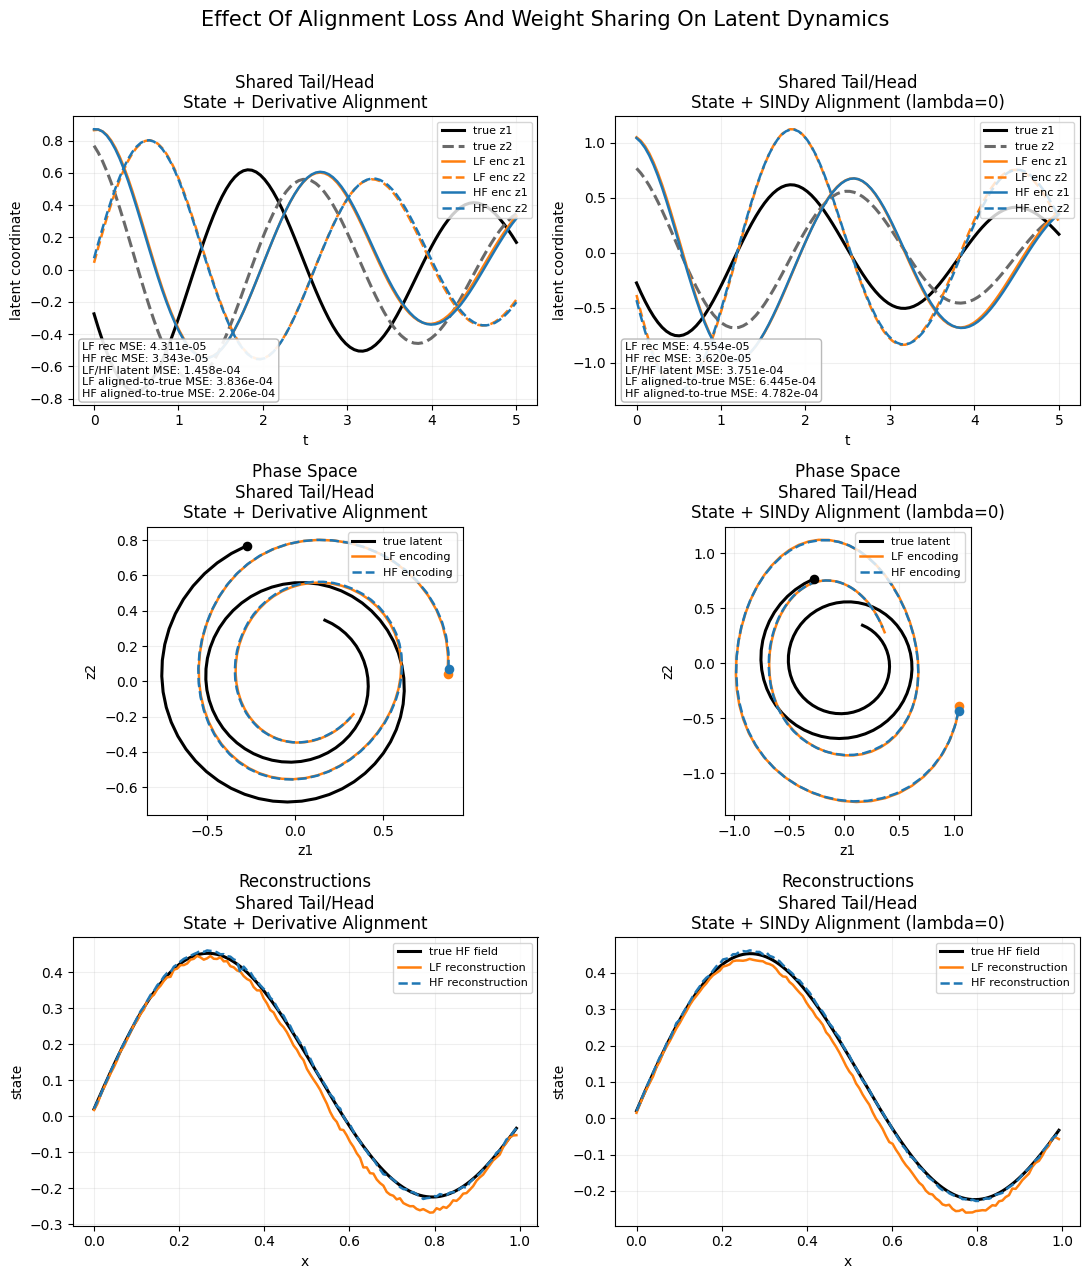

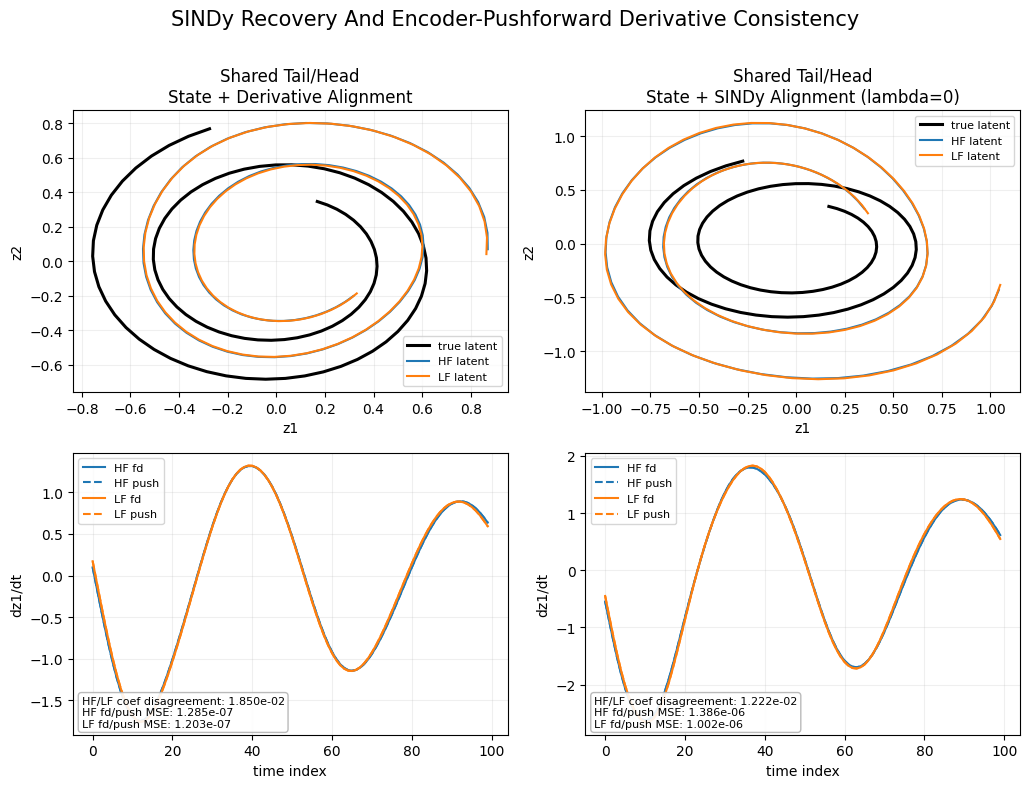

In [14]:
sample_index = 0
time_index = -1

fig, _ = create_sharing_figure(
    dynamics_enforced_results,
    sample_index=sample_index,
    time_index=time_index,
)
plt.show()

fig, _ = create_dynamics_figure(
    dynamics_enforced_analysis,
    sample_index=sample_index,
)
plt.show()


### Interpretation Of The Dynamics-Enforced Variants

- The **derivative-alignment** variant directly tries to collapse LF and HF latent velocities over time.
- The **SINDy-alignment** formulation is more structural: it tries to make LF and HF induce the same polynomial latent model.
- The derivative loss is local in time, while the SINDy-coefficient loss is global over the whole training trajectories.
- In the current notebook configuration, however, `\lambda_{sindy} = 0`, so the SINDy branch is effectively disabled and should be read as a documented extension rather than an active penalty.

So this section should currently be interpreted as a first extension beyond plain state alignment, with the derivative-matching loss as the active dynamics-enforcement mechanism.


## 18. Dynamics-Only Run Without State Alignment

We now repeat the previous experiment, but remove the explicit state-alignment term by setting `\lambda_{align} = 0`.

So the active objective becomes

$$
\mathcal{L} = \mathcal{L}_{rec} + \lambda_{der}\,\mathcal{L}_{der},
$$

with

$$
\mathcal{L}_{der} = \|\dot Z_{LF} - \dot Z_{HF}\|_F^2.
$$

This isolates the effect of the **dynamics constraint alone**, without explicitly forcing the LF and HF latent states to coincide.

Because `\lambda_{sindy} = 0` in the current configuration, the only active dynamics-only run below is the derivative-alignment variant.


In [15]:
from mfaesindy.experiments.latent_dynamics.study import RegimeConfig

dynamics_only_regimes = (
    RegimeConfig(
        name='shared_with_derivative_only',
        share_encoder_tail=True,
        share_decoder_head=True,
        lambda_align=0.0,
        lambda_derivative=1.0,
        lambda_sindy=0.0,
    ),
)

dynamics_only_results = run_full_study(
    SharingStudyConfig(dataset=dataset_config),
    regimes=dynamics_only_regimes,
)
dynamics_only_analysis = analyze_dynamics_results(dynamics_only_results)


In [16]:
library_terms = ['1', 'z1', 'z2', 'z1^2', 'z1 z2', 'z2^2']

def print_coefficients(title, coefficients):
    print(title)
    print('  basis      dz1/dt        dz2/dt')
    for term, row in zip(library_terms, coefficients):
        print(f"  {term:>5s}  {row[0]: .3e}  {row[1]: .3e}")

regime_key = 'shared_with_derivative_only'
metrics = dynamics_only_results['regimes'][regime_key]['metrics']
regime = dynamics_only_analysis['regimes'][regime_key]

print('Shared Tail/Head | Derivative Alignment Only')
print(format_reconstruction_metrics(metrics))
print(f"Train derivative alignment MSE: {metrics['train_derivative_alignment_mse']:.3e}")
print(f"Train SINDy alignment MSE     : {metrics['train_sindy_alignment_mse']:.3e}")
print(f"HF/LF coefficient disagreement: {regime['hf_lf_coefficient_disagreement']:.3e}")
print(f"HF fd vs pushforward MSE      : {regime['hf_fd_vs_pushforward_mse']:.3e}")
print(f"LF fd vs pushforward MSE      : {regime['lf_fd_vs_pushforward_mse']:.3e}")
print_coefficients('HF learned coefficients', regime['hf_coefficients'])
print_coefficients('LF learned coefficients', regime['lf_coefficients'])


Shared Tail/Head | Derivative Alignment Only
LF rec MSE: 3.339e-05
HF rec MSE: 2.981e-05
LF/HF latent MSE: 2.504e-03
LF aligned-to-true MSE: 3.957e-04
HF aligned-to-true MSE: 2.504e-04
Train derivative alignment MSE: 6.912e-04
Train SINDy alignment MSE     : 3.213e-03
HF/LF coefficient disagreement: 7.568e-02
HF fd vs pushforward MSE      : 1.981e-07
LF fd vs pushforward MSE      : 2.087e-07
HF learned coefficients
  basis      dz1/dt        dz2/dt
      1   4.144e-02   5.091e-02
     z1  -1.768e-01   2.212e+00
     z2  -1.813e+00  -1.289e-01
   z1^2   1.213e-01   1.110e-01
  z1 z2   1.748e-01  -3.079e-01
   z2^2  -1.765e-01   0.000e+00
LF learned coefficients
  basis      dz1/dt        dz2/dt
      1   0.000e+00   2.172e-01
     z1  -1.519e-01   2.246e+00
     z2  -1.817e+00  -1.477e-01
   z1^2   2.136e-01   9.174e-02
  z1 z2   1.728e-01  -3.220e-01
   z2^2  -9.512e-02  -3.076e-02


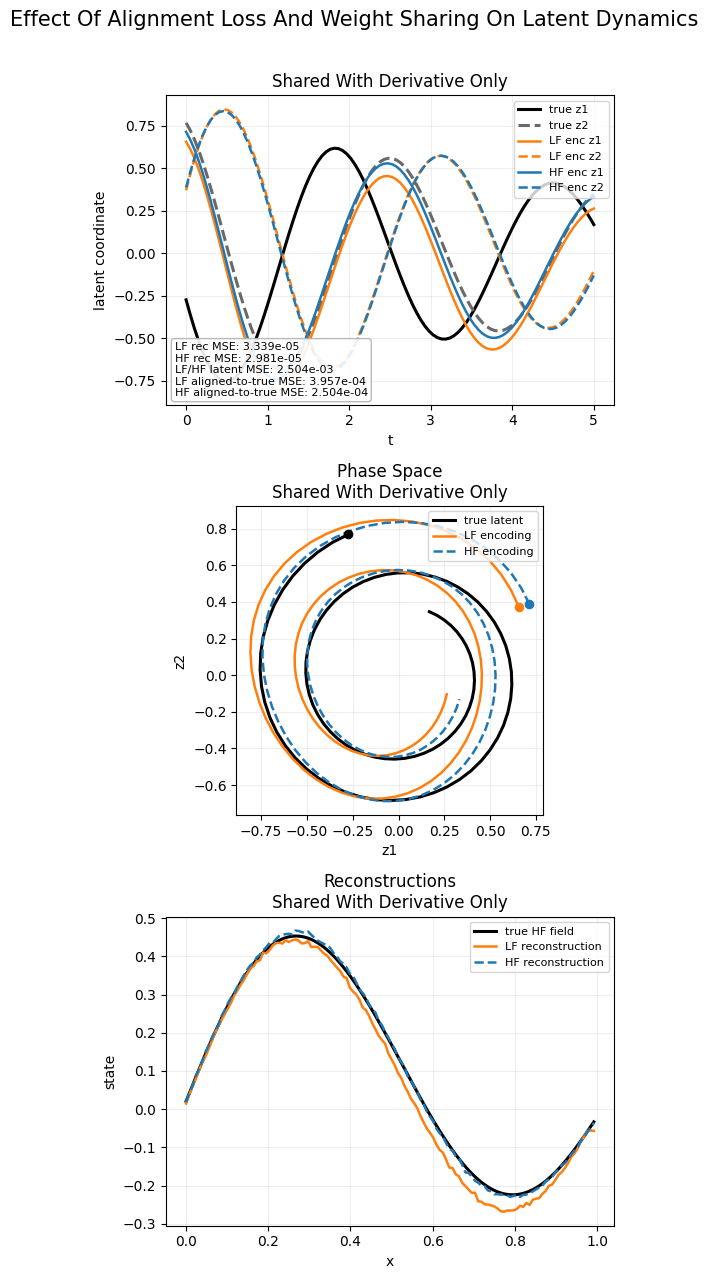

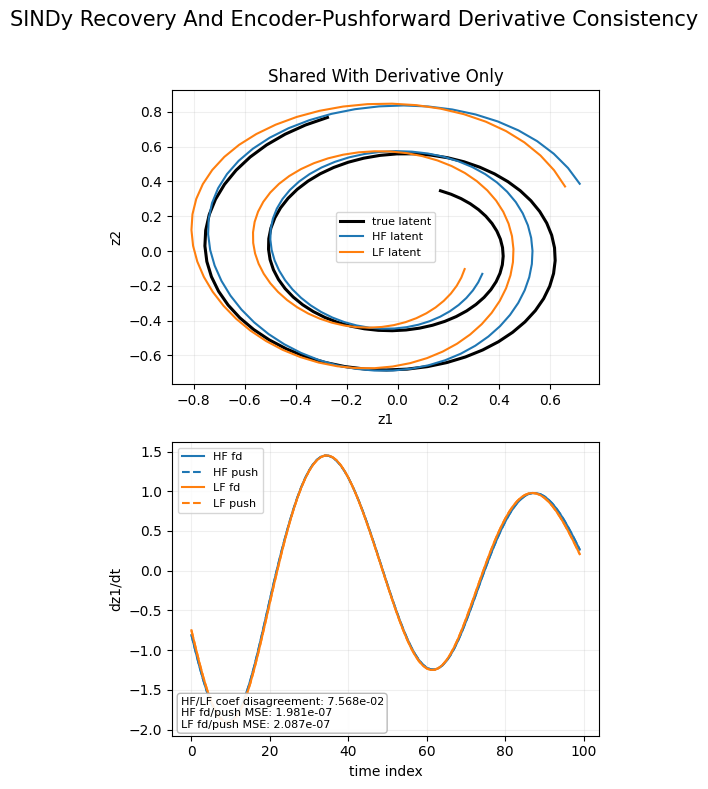

In [17]:
sample_index = 0
time_index = -1

fig, _ = create_sharing_figure(
    dynamics_only_results,
    sample_index=sample_index,
    time_index=time_index,
)
plt.show()

fig, _ = create_dynamics_figure(
    dynamics_only_analysis,
    sample_index=sample_index,
)
plt.show()


### Interpretation Of The Dynamics-Only Run

- This run tests whether matching LF/HF **latent velocities alone** is enough to recover compatible latent states and models.
- Because `\lambda_{align} = 0`, any LF/HF agreement that appears here is not coming from an explicit state-matching penalty.
- If this performs much worse than the state-plus-derivative variant, then the state-alignment term is doing important stabilizing work.
- If it remains competitive, that would suggest that the dynamics constraint itself is strong enough to organize the latent space.
